# Universe discovery — airline monthly rotating backtest

Exploratory discovery run (not sealed STAR OOS). Screens nested airline leaves with the method.md gated pipeline, rebuilds the book **monthly**, trades with adaptive z (2 × HL), OLS hedge **252**, entry |z| > 2, exit at mean. Demoted pairs hold to normal z-exit.

| Knob | Value | Why |
|------|--------|-----|
| β / OLS | 252 | Stack default (OLS_WINDOW_STAR / H-005) |
| Discovery L | 252 | Trailing year at each month-end |
| z window | clip(2 × HL_{t-1}, 20, 120) | daptive_zscore |
| Entry / exit | |z| > 2 / mean | entry_z=2, exit_z=0 |
| Rebalance | Month-end → next session | Demote = block new entries only |
| Empty month | Flat / cash | No gate survivors → no new entries; open trades still exit on z |

Every month-end is retested. Empty-book months are valid (flat). Default universe: **50 US-listed airline/carrier candidates** in nested leaves (irline_pools.DEFAULT_AIRLINE_POOLS); fetch + Alpaca shortability prune the live set.

**Restart kernel and run all** so cells pick up the empty-pair_id fix (do not unpack schedule markers as y|x).

Edit POOLS in section 0 to change the universe.


## 0. Imports & Config

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

cur = os.path.abspath(os.getcwd())
ROOT = cur
for _ in range(12):
    if os.path.isfile(os.path.join(cur, "pyproject.toml")) and os.path.isdir(
        os.path.join(cur, "02_research")
    ):
        ROOT = cur
        break
    parent = os.path.dirname(cur)
    if parent == cur:
        break
    cur = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DISC = os.path.join(ROOT, "02_research", "s2_coint", "notebooks", "universe_discovery")
if DISC not in sys.path:
    sys.path.insert(0, DISC)

from backtest.s2_coint.diagnosis import gross_returns_from_net
from backtest.s2_coint.rotation import SLOT_WEIGHT, book_composition
from backtest.s2_coint.tearsheet import (
    cvar,
    equity_from_returns,
    monthly_returns,
    oos_headline_metrics,
    plot_drawdown,
    plot_equity_net_gross,
    plot_monthly_heatmap,
)
from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.s2_coint_store import build_pair_panel, compute_adaptive_zscore
from data.processing.s2_universe import pool_tickers
from strategies.s2_coint.config import S2SimConfig
from strategies.s2_coint.metrics import (
    book_returns_to_calendar,
    metrics_from_returns,
    panel_session_dates,
)

from airline_pools import (
    DEFAULT_AIRLINE_POOLS,
    airline_ticker_count,
    filter_pools_to_tickers,
)
from screen import (
    ADV_WINDOW,
    CORR_MIN,
    COST_PROFILE_DEFAULT,
    COST_TO_MOVE_MAX,
    EMPTY_BOOK_PAIR_ID,
    FDR_Q,
    HL_MAX,
    LOOKBACK_BARS,
    MIN_ADV_USD,
    OLS_WINDOW,
    PERSISTENCE_FLOOR,
    Z_ENTRY,
    active_pair_ids,
    build_monthly_schedule,
    funnel_counts,
    month_end_rebalance_dates,
    screen_universe,
    simulate_monthly_rotating_book,
)

# --- editable universe: ~50 airline candidates in nested leaves ---
# Leaves keep pairs within theme. Alpaca + fetch filters prune the live set below.
POOLS = {k: list(v) for k, v in DEFAULT_AIRLINE_POOLS.items()}

START = "2015-01-01"
END = None  # through latest available
BAR = "1d"
CAP_GLOBAL = 6
CAP_PER_POOL = 2

# Shortability: set True only when Alpaca credentials are unavailable.
SKIP_SHORTABILITY = False

# Exploratory inference only (not STAR variant ledger).
N_TRIALS_LOCAL = 1

print("ROOT", ROOT)
print("candidate tickers", airline_ticker_count(POOLS), "leaves", list(POOLS))
print(
    "gates",
    dict(
        OLS_WINDOW=OLS_WINDOW,
        LOOKBACK_BARS=LOOKBACK_BARS,
        CORR_MIN=CORR_MIN,
        FDR_Q=FDR_Q,
        HL_MAX=HL_MAX,
        PERSISTENCE_FLOOR=PERSISTENCE_FLOOR,
        MIN_ADV_USD=MIN_ADV_USD,
        COST_TO_MOVE_MAX=COST_TO_MOVE_MAX,
        Z_ENTRY=Z_ENTRY,
    ),
)


ROOT c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
candidate tickers 50 leaves ['us_majors', 'us_ulcc', 'us_regional', 'us_cargo_charter', 'latam', 'europe_adr', 'asia_adr', 'air_taxi_evtol']
gates {'OLS_WINDOW': 252, 'LOOKBACK_BARS': 252, 'CORR_MIN': 0.8, 'FDR_Q': 0.1, 'HL_MAX': 40.0, 'PERSISTENCE_FLOOR': 0.4, 'MIN_ADV_USD': 5000000.0, 'COST_TO_MOVE_MAX': 0.25, 'Z_ENTRY': 2.0}


## 1. Data

In [2]:
tickers = pool_tickers(POOLS)
ohlc_by_ticker: dict[str, pd.DataFrame] = {}
fetch_fail: list[str] = []
for t in tickers:
    try:
        raw = fetch_ohlcv(t, START, END, interval=BAR, auto_adjust=False)
    except Exception as exc:
        print("WARN fetch failed", t, type(exc).__name__, exc)
        fetch_fail.append(t)
        continue
    if raw is None or raw.empty:
        print("WARN empty", t)
        fetch_fail.append(t)
        continue
    g = raw.copy()
    g["date"] = pd.to_datetime(g["date"])
    g = g.set_index("date").sort_index()
    ohlc_by_ticker[t] = g[["open", "high", "low", "close", "volume"]].astype(float)

# Keep only leaves that still have >= 2 names with price history.
POOLS = filter_pools_to_tickers(POOLS, list(ohlc_by_ticker))
tickers = pool_tickers(POOLS)
closes = {t: df["close"] for t, df in ohlc_by_ticker.items() if t in tickers}
ohlc_by_ticker = {t: ohlc_by_ticker[t] for t in tickers}
sessions = (
    pd.DatetimeIndex(sorted(set().union(*[set(s.index) for s in closes.values()])))
    if closes
    else pd.DatetimeIndex([])
)
print("fetch_fail", fetch_fail)
print("priced tickers", len(tickers), tickers)
print("live leaves", {k: v for k, v in POOLS.items()})
print(
    "sessions",
    len(sessions),
    sessions.min() if len(sessions) else None,
    "→",
    sessions.max() if len(sessions) else None,
)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HA"}}}
$HA: possibly delisted; no timezone found

1 Failed download:
['HA']: possibly delisted; no timezone found
yfinance returned empty for chunk ['HA'] (attempt 1/3)
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HA"}}}
$HA: possibly delisted; no timezone found

1 Failed download:
['HA']: possibly delisted; no timezone found
yfinance returned empty for chunk ['HA'] (attempt 2/3)
$HA: possibly delisted; no timezone found

1 Failed download:
['HA']: possibly delisted; no timezone found


WARN empty HA


$SNCY: possibly delisted; no timezone found

1 Failed download:
['SNCY']: possibly delisted; no timezone found
yfinance returned empty for chunk ['SNCY'] (attempt 1/3)
$SNCY: possibly delisted; no timezone found

1 Failed download:
['SNCY']: possibly delisted; no timezone found
yfinance returned empty for chunk ['SNCY'] (attempt 2/3)
$SNCY: possibly delisted; no timezone found

1 Failed download:
['SNCY']: possibly delisted; no timezone found


WARN empty SNCY


$SAVE: possibly delisted; no timezone found

1 Failed download:
['SAVE']: possibly delisted; no timezone found
yfinance returned empty for chunk ['SAVE'] (attempt 1/3)
$SAVE: possibly delisted; no timezone found

1 Failed download:
['SAVE']: possibly delisted; no timezone found
yfinance returned empty for chunk ['SAVE'] (attempt 2/3)
$SAVE: possibly delisted; no timezone found

1 Failed download:
['SAVE']: possibly delisted; no timezone found


...

WARN empty BLDE


$LILM: possibly delisted; no timezone found

1 Failed download:
['LILM']: possibly delisted; no timezone found
yfinance returned empty for chunk ['LILM'] (attempt 1/3)
$LILM: possibly delisted; no timezone found

1 Failed download:
['LILM']: possibly delisted; no timezone found
yfinance returned empty for chunk ['LILM'] (attempt 2/3)
$LILM: possibly delisted; no timezone found

1 Failed download:
['LILM']: possibly delisted; no timezone found


WARN empty LILM


$ZK: possibly delisted; no timezone found

1 Failed download:
['ZK']: possibly delisted; no timezone found
yfinance returned empty for chunk ['ZK'] (attempt 1/3)
$ZK: possibly delisted; no timezone found

1 Failed download:
['ZK']: possibly delisted; no timezone found
yfinance returned empty for chunk ['ZK'] (attempt 2/3)
$ZK: possibly delisted; no timezone found

1 Failed download:
['ZK']: possibly delisted; no timezone found


WARN empty ZK
fetch_fail ['HA', 'SNCY', 'SAVE', 'FLYY', 'MESA', 'ATSG', 'AAWW', 'GOL', 'EZJZY', 'NRYAY', 'CEA', 'ZNH', 'BLDE', 'LILM', 'ZK']
priced tickers 35 ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'ULCC', 'ALGT', 'SKYW', 'RJET', 'FLYX', 'UP', 'CPA', 'VLRS', 'AZUL', 'LTM', 'AERO', 'RYAAY', 'ICAGY', 'DLAKY', 'AFLYY', 'FINMY', 'SINGY', 'CPCAY', 'JAPSY', 'ALNPY', 'AIRYY', 'JOBY', 'SRFM', 'SOAR', 'JTAI', 'ACHR', 'EVTL', 'EH', 'PONY']
live leaves {'us_majors': ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU'], 'us_ulcc': ['ULCC', 'ALGT'], 'us_regional': ['SKYW', 'RJET'], 'us_cargo_charter': ['FLYX', 'UP'], 'latam': ['CPA', 'VLRS', 'AZUL', 'LTM', 'AERO'], 'europe_adr': ['RYAAY', 'ICAGY', 'DLAKY', 'AFLYY', 'FINMY'], 'asia_adr': ['SINGY', 'CPCAY', 'JAPSY', 'ALNPY', 'AIRYY'], 'air_taxi_evtol': ['JOBY', 'SRFM', 'SOAR', 'JTAI', 'ACHR', 'EVTL', 'EH', 'PONY']}
sessions 2936 2015-01-02 00:00:00 → 2026-09-04 00:00:00


In [3]:
shortable_by_ticker: dict[str, bool] | None = None
if SKIP_SHORTABILITY:
    print("SKIP_SHORTABILITY=True — shortability gate disabled")
else:
    try:
        from execution.brokers.alpaca_broker import (
            AlpacaBroker,
            S2_ALPACA_API_KEY,
            S2_ALPACA_SECRET_KEY,
        ) 

        broker = AlpacaBroker(
            paper=True,
            api_key_name=S2_ALPACA_API_KEY,
            secret_key_name=S2_ALPACA_SECRET_KEY,
        )
        rows = broker.get_asset_shortability(tickers)
        short_df = pd.DataFrame(rows)
        display(short_df)
        shortable_by_ticker = {
            str(r["ticker"]): bool(r.get("shortable")) and bool(r.get("found"))
            for r in rows
        }
        # Also require Alpaca found+shortable for the live pool (retail tradable shorts).
        keep = {t for t, ok in shortable_by_ticker.items() if ok}
        dropped = [t for t in tickers if t not in keep]
        if dropped:
            print("drop not shortable / not found on Alpaca:", dropped)
        POOLS = filter_pools_to_tickers(POOLS, keep)
        tickers = pool_tickers(POOLS)
        ohlc_by_ticker = {t: ohlc_by_ticker[t] for t in tickers if t in ohlc_by_ticker}
        closes = {t: ohlc_by_ticker[t]["close"] for t in tickers}
        sessions = (
            pd.DatetimeIndex(sorted(set().union(*[set(s.index) for s in closes.values()])))
            if closes
            else pd.DatetimeIndex([])
        )
        shortable_by_ticker = {t: True for t in tickers}
        print("Alpaca-shortable tickers", len(tickers), tickers)
        print("live leaves after shortability", {k: v for k, v in POOLS.items()})
    except Exception as exc:
        print("Alpaca shortability unavailable:", type(exc).__name__, exc)
        print("Falling back to SKIP_SHORTABILITY=True for this run")
        SKIP_SHORTABILITY = True
        shortable_by_ticker = None


,ticker,alpaca_symbol,shortable,easy_to_borrow,found,error
0,DAL,DAL,True,True,True,
1,UAL,UAL,True,True,True,
2,AAL,AAL,True,True,True,
3,LUV,LUV,True,True,True,
4,ALK,ALK,True,True,True,
5,JBLU,JBLU,True,True,True,
6,ULCC,ULCC,True,True,True,
7,ALGT,ALGT,True,True,True,
8,SKYW,SKYW,True,True,True,
9,RJET,RJET,True,True,True,


drop not shortable / not found on Alpaca: ['FLYX', 'UP', 'AZUL', 'AERO', 'ICAGY', 'DLAKY', 'AFLYY', 'FINMY', 'SINGY', 'CPCAY', 'JAPSY', 'ALNPY', 'AIRYY', 'SRFM', 'SOAR', 'JTAI', 'EVTL']
Alpaca-shortable tickers 17 ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'ULCC', 'ALGT', 'SKYW', 'RJET', 'CPA', 'VLRS', 'LTM', 'JOBY', 'ACHR', 'EH', 'PONY']
live leaves after shortability {'us_majors': ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU'], 'us_ulcc': ['ULCC', 'ALGT'], 'us_regional': ['SKYW', 'RJET'], 'latam': ['CPA', 'VLRS', 'LTM'], 'air_taxi_evtol': ['JOBY', 'ACHR', 'EH', 'PONY']}


## 2. One-shot screen sanity

Run the full method.md funnel at a fixed `asof` (mid-sample) to inspect survivors and reject reasons.

In [4]:
if len(sessions) < LOOKBACK_BARS + 60:
    asof_sanity = sessions[-1] if len(sessions) else pd.Timestamp(START)
else:
    asof_sanity = sessions[LOOKBACK_BARS + (len(sessions) - LOOKBACK_BARS) // 2]

screen_once = screen_universe(
    ohlc_by_ticker,
    POOLS,
    asof=asof_sanity,
    lookback_bars=LOOKBACK_BARS,
    ols_window=OLS_WINDOW,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    shortable_by_ticker=shortable_by_ticker,
    skip_shortability=SKIP_SHORTABILITY,
    cost_profile=COST_PROFILE_DEFAULT,
)
print("asof", asof_sanity)
print("funnel")
display(funnel_counts(screen_once).to_frame())
display(
    screen_once.sort_values(["passed", "pvalue"], ascending=[False, True])[
        [
            "pair_id",
            "pool",
            "corr",
            "pvalue",
            "fdr_pass",
            "discovery_half_life",
            "pct_adf_lt_005",
            "rt_cost_bps",
            "z2_move_bps",
            "cost_to_move",
            "exclude_reason",
            "passed",
            "auto_selected",
        ]
    ]
)

asof 2021-05-04 00:00:00
funnel


,n
exclude_reason,
not_passer,9
corr,8
liquidity,5
persistence,3
,1


,pair_id,pool,corr,pvalue,fdr_pass,discovery_half_life,pct_adf_lt_005,rt_cost_bps,z2_move_bps,cost_to_move,exclude_reason,passed,auto_selected
13,JBLU|LUV,us_majors,0.846365,0.000045,True,7.974797,0.629921,13.2,1217.589621,0.010841,,True,True
8,UAL|JBLU,us_majors,0.882016,0.002798,True,9.571332,0.102362,13.2,1462.303280,0.009027,persistence,False,False
14,JBLU|ALK,us_majors,0.897587,0.006673,True,6.078690,0.173228,13.2,813.245662,0.016231,persistence,False,False
7,UAL|ALK,us_majors,0.891439,0.017772,True,14.580259,0.141732,13.2,1537.976152,0.008583,persistence,False,False
6,UAL|LUV,us_majors,0.856667,0.053438,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
12,LUV|ALK,us_majors,0.876207,0.083521,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
2,DAL|LUV,us_majors,0.892699,0.163803,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
0,UAL|DAL,us_majors,0.936406,0.187312,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
11,JBLU|AAL,us_majors,0.805078,0.270615,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
3,DAL|ALK,us_majors,0.907934,0.380854,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False


## 3. Monthly schedule

Full gated screen at **every** month-end; active set effective next session. First rebalances need `LOOKBACK_BARS` history.

Months with zero survivors are recorded as empty-book markers (`pair_id == ""`): the book goes flat instead of keeping the prior month's pairs.


In [5]:
rebals = month_end_rebalance_dates(sessions)
# Need a full trailing lookback before the first usable screen.
if len(sessions) > LOOKBACK_BARS:
    first_ok = sessions[LOOKBACK_BARS - 1]
    rebals = [d for d in rebals if d >= first_ok]

schedule = build_monthly_schedule(
    ohlc_by_ticker,
    POOLS,
    sessions,
    lookback_bars=LOOKBACK_BARS,
    ols_window=OLS_WINDOW,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    rebalance_dates=rebals,
    shortable_by_ticker=shortable_by_ticker,
    skip_shortability=SKIP_SHORTABILITY,
    cost_profile=COST_PROFILE_DEFAULT,
)
n_reb = int(schedule["rebalance_date"].nunique()) if not schedule.empty else 0
n_empty = (
    int((schedule["pair_id"].astype(str).str.strip() == EMPTY_BOOK_PAIR_ID).sum())
    if not schedule.empty
    else 0
)
n_live = len(active_pair_ids(schedule))
print("month-end retests", n_reb, "| empty-book marker rows", n_empty, "| unique live pairs", n_live)
print("schedule rows", len(schedule))
display(schedule.head(20))
live_sched = schedule.loc[schedule["pair_id"].astype(str).str.strip() != EMPTY_BOOK_PAIR_ID]
if not live_sched.empty:
    display(book_composition(live_sched).head(20))
else:
    print("No months selected any pairs — book stays flat for the whole sample (still a valid run).")


month-end retests 129 | empty-book marker rows 109 | unique live pairs 10
schedule rows 136


,rebalance_date,effective_date,pair_id,pool,pvalue,rank
0,2015-12-31,2016-01-04,,,NaN,0
1,2016-01-29,2016-02-01,,,NaN,0
2,2016-02-29,2016-03-01,,,NaN,0
3,2016-03-31,2016-04-01,,,NaN,0
4,2016-04-29,2016-05-02,,,NaN,0
5,2016-05-31,2016-06-01,,,NaN,0
6,2016-06-30,2016-07-01,,,NaN,0
7,2016-07-29,2016-08-01,,,NaN,0
8,2016-08-31,2016-09-01,,,NaN,0
9,2016-09-30,2016-10-03,,,NaN,0


,effective_date,pool,n_pairs
0,2020-07-01,us_majors,2
1,2020-08-03,us_majors,2
2,2020-09-01,us_majors,2
3,2020-10-01,us_majors,2
4,2021-03-01,us_majors,1
5,2021-04-01,us_majors,2
6,2021-05-03,us_majors,1
7,2021-06-01,us_majors,1
8,2021-07-01,us_majors,1
9,2021-08-02,us_majors,2


## 4. Panel (OLS 252 + adaptive z = 2×HL)

In [6]:
def _legs_from_pair_id(pid: str) -> tuple[str, str] | None:
    """Parse ``y|x``; return None for empty-book markers or malformed ids."""
    p = str(pid).strip()
    if not p or p == EMPTY_BOOK_PAIR_ID or "|" not in p:
        return None
    parts = p.split("|")
    if len(parts) != 2 or not parts[0] or not parts[1]:
        return None
    return parts[0], parts[1]


live_pairs = active_pair_ids(schedule)
if not live_pairs:
    # Flat universe: still build a date spine from closes so metrics/plots run.
    any_close = next(iter(ohlc_by_ticker.values()))
    panel = pd.DataFrame({"date": pd.to_datetime(any_close.index)})
    panel["pair_id"] = "__FLAT__"
    panel["spread"] = np.nan
    panel["half_life"] = np.nan
    panel["z"] = np.nan
    panel["beta"] = np.nan
    for col in ("open_y", "high_y", "low_y", "close_y", "open_x", "high_x", "low_x", "close_x"):
        panel[col] = np.nan
    print("No live pairs in schedule — using flat date spine only (", len(panel), "sessions)")
else:
    pair_tuples = []
    seen = set()
    for pid in live_pairs:
        legs = _legs_from_pair_id(pid)
        if legs is None:
            continue
        if legs in seen:
            continue
        seen.add(legs)
        pair_tuples.append(legs)

    if not pair_tuples:
        raise RuntimeError("live_pairs present but none parsed as y|x — check schedule pair_id values")

    panel = build_pair_panel(
        ohlc_by_ticker,
        pair_tuples,
        ols_window=OLS_WINDOW,
        z_window=60,  # placeholder; overwritten by adaptive z below
        hl_window=OLS_WINDOW,
        hedge="ols",
        include_adf_pvalue=False,
    )
    parts = []
    for pid, g in panel.groupby("pair_id", sort=False):
        g = g.sort_values("date").copy()
        g["z"] = compute_adaptive_zscore(
            g["spread"], g["half_life"], z_min=20, z_max=120
        ).to_numpy(dtype=float)
        parts.append(g)
    panel = pd.concat(parts, ignore_index=True)
    print("panel rows", len(panel), "pairs", panel["pair_id"].nunique())
    display(panel.head(3))


panel rows 29360 pairs 10


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life
0,2015-01-02,AAL|DAL,AAL,DAL,54.279999,54.599998,53.070000,53.910000,49.919998,50.009998,48.709999,49.180000,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,AAL|DAL,AAL,DAL,54.369999,54.540001,53.340000,53.880001,49.459999,49.480000,47.810001,48.360001,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,AAL|DAL,AAL,DAL,54.270000,54.430000,52.130001,53.040001,48.549999,48.740002,46.250000,47.220001,NaN,NaN,NaN,NaN,NaN


## 5. Backtest (full S2 engine)

Signal at close `t`, fill open `t+1`. `overlap_mode=never_allow`. Costs: `US_ALPACA`.

In [7]:
cfg = S2SimConfig(
    hedge="ols",
    bar=BAR,
    entry_z=float(Z_ENTRY),
    exit_z=0.0,
    ols_window=OLS_WINDOW,
    z_window=60,
    hl_window=OLS_WINDOW,
    adf_window=OLS_WINDOW,
    z_window_mode="adaptive",
    z_clip_min=20,
    z_clip_max=120,
    entry_mode="trad_z",
    exit_mode="mean_only",
    break_mode="off",
    trend_mode="off",
    overlap_mode="never_allow",
    size_mode="equal",
    vol_mode="fixed_k",
    cost_profile=COST_PROFILE_DEFAULT,
    use_hedge_ratio_sizing=True,
)

sim = simulate_monthly_rotating_book(
    panel,
    schedule,
    cfg,
    slot_weight=SLOT_WEIGHT,
    apply_short_bans=False,
)
master_dates = (
    panel_session_dates(panel)
    if "pair_id" in panel.columns
    else pd.DatetimeIndex(pd.to_datetime(panel["date"])).unique().sort_values()
)
if len(master_dates) == 0 and len(sessions):
    master_dates = sessions
net = book_returns_to_calendar(sim["returns"], master_dates)
trades = sim["trades"] if isinstance(sim["trades"], pd.DataFrame) else pd.DataFrame()
gross = gross_returns_from_net(net, trades)
rebal_log = sim.get("rebalance_log", pd.DataFrame())

print("n_days", len(net), "n_trades", len(trades), "live pairs ever", len(active_pair_ids(schedule)))
display(rebal_log.head(15) if not rebal_log.empty else rebal_log)


n_days 2936 n_trades 26 live pairs ever 10


,rebalance_date,effective_date,n_active,promoted,demoted,flipped
0,2015-12-31,2016-01-04,0,,,
1,2016-01-29,2016-02-01,0,,,
2,2016-02-29,2016-03-01,0,,,
3,2016-03-31,2016-04-01,0,,,
4,2016-04-29,2016-05-02,0,,,
5,2016-05-31,2016-06-01,0,,,
6,2016-06-30,2016-07-01,0,,,
7,2016-07-29,2016-08-01,0,,,
8,2016-08-31,2016-09-01,0,,,
9,2016-09-30,2016-10-03,0,,,


## 6. Universe effectiveness report

**Exploratory discovery** — not sealed STAR OOS. Use this scoreboard to judge whether the airline leaf is worth expanding.

In [8]:
s1_weekly = None
s1_path = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"
)
if os.path.isfile(s1_path):
    s1 = pd.read_parquet(s1_path)
    # Best-effort: first numeric column as weekly sleeve returns.
    if isinstance(s1, pd.DataFrame) and not s1.empty:
        if "ret" in s1.columns:
            s1_weekly = pd.to_numeric(s1["ret"], errors="coerce")
            if "date" in s1.columns:
                s1_weekly.index = pd.to_datetime(s1["date"])
        else:
            num = s1.select_dtypes(include=[np.number])
            if not num.empty:
                s1_weekly = num.iloc[:, 0]

headline = oos_headline_metrics(
    net,
    gross,
    trades=trades,
    s1_weekly=s1_weekly,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=None,
)
headline["cvar_5"] = float(cvar(net, alpha=0.05))
print("=== headline (net primary) ===")
display(headline.to_frame("value"))

=== headline (net primary) ===


,value
ann_sharpe_net,0.284274
ann_sharpe_gross,0.579491
sortino,0.443196
calmar,0.131526
max_drawdown,-0.020947
cagr,0.002755
total_return,0.032575
psr,0.000000
dsr_local,1.000000
dsr_stack,NaN


In [9]:
# Screen funnel at last rebalance (universe quality, not just sim PnL)
if schedule.empty:
    print("No rebalance schedule — skip last-funnel display")
    screen_last = pd.DataFrame()
else:
    last_reb = schedule["rebalance_date"].max()
    screen_last = screen_universe(
        ohlc_by_ticker,
        POOLS,
        asof=last_reb,
        lookback_bars=LOOKBACK_BARS,
        ols_window=OLS_WINDOW,
        per_pool_cap=CAP_PER_POOL,
        global_cap=CAP_GLOBAL,
        shortable_by_ticker=shortable_by_ticker,
        skip_shortability=SKIP_SHORTABILITY,
        cost_profile=COST_PROFILE_DEFAULT,
    )
    print("funnel @", last_reb)
    display(funnel_counts(screen_last).to_frame("n"))

live_sched = (
    schedule.loc[schedule["pair_id"].astype(str).str.strip() != EMPTY_BOOK_PAIR_ID]
    if not schedule.empty
    else schedule
)
if not live_sched.empty:
    print("book composition (head)")
    display(book_composition(live_sched).head(20))
else:
    print("book composition: empty (all months flat)")

if not schedule.empty:
    active_per_reb = (
        schedule.assign(
            _live=schedule["pair_id"].astype(str).str.strip().ne(EMPTY_BOOK_PAIR_ID)
        )
        .groupby("effective_date")["_live"]
        .sum()
        .rename("n_active")
        .reset_index()
    )
    display(active_per_reb.tail(12))


funnel @ 2026-08-31 00:00:00


,n
exclude_reason,
corr,17
liquidity,6
not_passer,3


book composition (head)


,effective_date,pool,n_pairs
0,2020-07-01,us_majors,2
1,2020-08-03,us_majors,2
2,2020-09-01,us_majors,2
3,2020-10-01,us_majors,2
4,2021-03-01,us_majors,1
5,2021-04-01,us_majors,2
6,2021-05-03,us_majors,1
7,2021-06-01,us_majors,1
8,2021-07-01,us_majors,1
9,2021-08-02,us_majors,2


,effective_date,n_active
117,2025-10-01,0
118,2025-11-03,0
119,2025-12-01,0
120,2026-01-02,0
121,2026-02-02,0
122,2026-03-02,0
123,2026-04-01,0
124,2026-05-01,0
125,2026-06-01,0
126,2026-07-01,0


In [10]:
# Per-pair contribution (catch single-pair concentration)
pair_rows = []
for pid, pr in (sim.get("pair_returns") or {}).items():
    r = book_returns_to_calendar(pr * SLOT_WEIGHT, master_dates)
    m = metrics_from_returns(r)
    g = (
        panel.loc[panel["pair_id"].astype(str) == str(pid)]
        if "half_life" in panel.columns
        else pd.DataFrame()
    )
    hl = pd.to_numeric(g["half_life"], errors="coerce") if not g.empty else pd.Series(dtype=float)
    hl_med = float(hl[np.isfinite(hl)].median()) if len(hl) and hl.notna().any() else float("nan")
    n_tr = 0
    if not trades.empty and "pair_id" in trades.columns:
        n_tr = int((trades["pair_id"].astype(str) == str(pid)).sum())
    hold = float("nan")
    if not trades.empty and "pair_id" in trades.columns and "hold_bars" in trades.columns:
        sub = trades.loc[trades["pair_id"].astype(str) == str(pid), "hold_bars"]
        if len(sub):
            hold = float(pd.to_numeric(sub, errors="coerce").median())
    pair_rows.append(
        {
            "pair_id": pid,
            "ann_sharpe": m["ann_sharpe"],
            "max_drawdown": m["max_drawdown"],
            "total_contrib": float((1.0 + r).prod() - 1.0) if len(r) else float("nan"),
            "n_trades": n_tr,
            "median_hold_bars": hold,
            "median_half_life": hl_med,
        }
    )
pair_table = pd.DataFrame(pair_rows)
if pair_table.empty:
    print("No pair-level returns (fully flat book).")
else:
    display(pair_table.sort_values("ann_sharpe", ascending=False))


,pair_id,ann_sharpe,max_drawdown,total_contrib,n_trades,median_hold_bars,median_half_life
5,LUV|ALK,0.524855,-0.000961,0.004704,3,4.0,24.465875
8,UAL|LUV,0.354559,-0.008443,0.012516,5,5.0,28.818255
0,AAL|UAL,0.212096,-0.010184,0.010787,3,18.0,25.489207
7,DAL|LUV,0.155143,-0.004617,0.004486,2,13.5,21.485606
4,DAL|JBLU,0.122187,-0.002276,0.001562,1,9.0,17.725785
3,JBLU|LUV,0.056265,-0.003720,0.001141,4,10.5,18.636160
1,AAL|DAL,0.044885,-0.010958,0.001922,4,14.5,22.154264
2,UAL|ALK,0.005169,-0.011378,0.000109,1,17.0,20.928467
6,ALK|LUV,-0.136408,-0.011325,-0.004837,3,14.0,26.296279


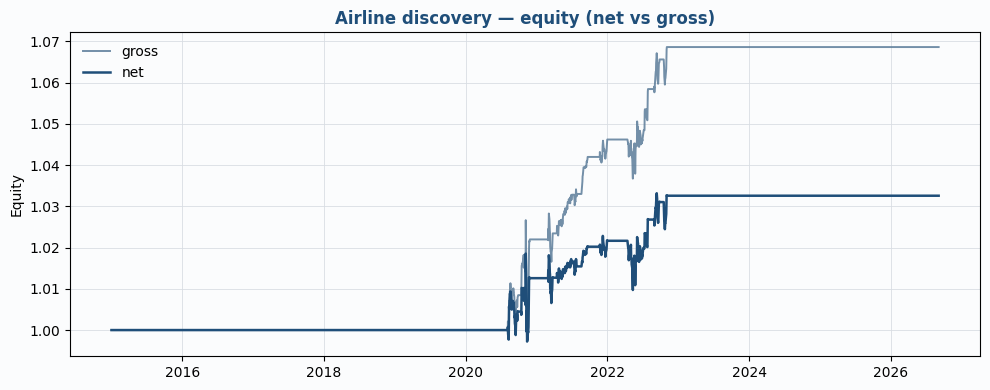

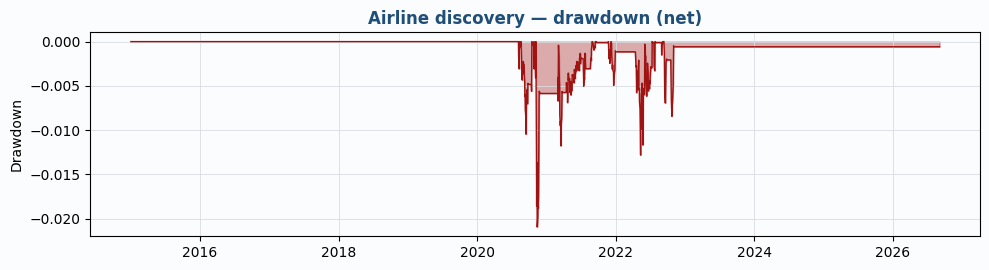

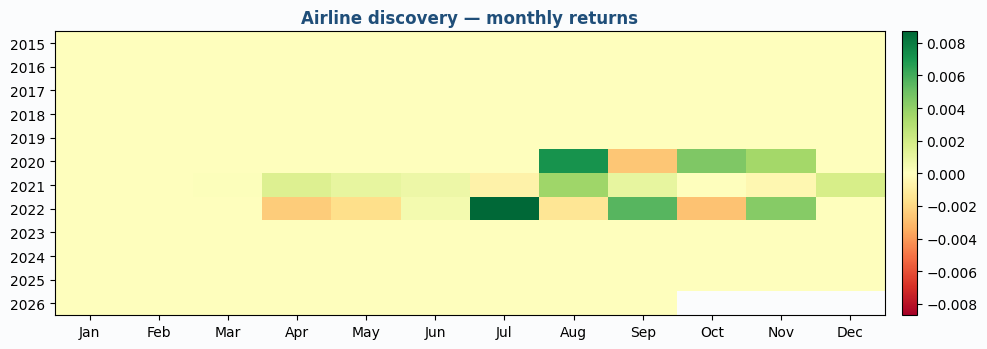

Done. Interpret headline Sharpe/Calmar/CAGR/CVaR/kurtosis together with the funnel and per-pair table.


In [11]:
eq = equity_from_returns(net)
fig = plot_equity_net_gross(net, gross, title="Airline discovery — equity (net vs gross)")
plt.show()
fig = plot_drawdown(net, title="Airline discovery — drawdown (net)")
plt.show()
mret = monthly_returns(net)
fig = plot_monthly_heatmap(mret, title="Airline discovery — monthly returns")
plt.show()

print("Done. Interpret headline Sharpe/Calmar/CAGR/CVaR/kurtosis together with the funnel and per-pair table.")